# Evaluation and Demo

Import libraries

In [20]:
import torch
from torchinfo import summary
import yaml
from training import Trainer
import os
from utils import get_data
from accelerate import Accelerator # for multigpu
from dotenv import load_dotenv
import numpy as np

load_dotenv()  # take environment variables from .env file

# accelerator for multigpu
accelerator = Accelerator()

##### Datasets and splits

In [21]:
# load and split dataset
from torchvision import transforms
from gripper_data import GripperDataset
from gripper_data_ref import GripperDatasetReference
from utils import split_dataset
from torch.utils.data import DataLoader

BATCH_SIZE = 32
torch.manual_seed(6) # for reproducibility

FULL_DATASET_PATH = os.getenv("BIG_DATASET_PATH") 
TOY_DATASET_PATH = os.getenv("DATASET_PATH")

FULL_DATASET_SPLIT = [70000,20000,10000] # train, val, test
TOY_DATASET_SPLIT = [8000, 2000, 300] # train, val, test

# Preprocessing transforms
top_img_shape = [720, 1280] # original image shape
resize_factor = 16
resize_shape = [int(x//resize_factor) for x in top_img_shape]
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        ])


Normal datasets

In [22]:
# -- Full dataset --
dataset = GripperDataset(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
torch.manual_seed(6) # for reproducibility
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, FULL_DATASET_SPLIT)
val_dataset_early_stopping, val_dataset_2 = split_dataset(val_dataset, [10000,10000])

print(f"\nOriginal dataset size: {len(dataset)}")
print(f"- Len train dataset: {len(train_dataset)}",
            f"- Len val dataset: {len(val_dataset)}",
            f"  - Len val dataset for early stopping: {len(val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(val_dataset_2)}",
            f"- Len test dataset: {len(test_dataset)}", sep="\n")


# -- Toy dataset --
toy_dataset = GripperDataset(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
toy_train_dataset, toy_val_dataset, toy_test_dataset = torch.utils.data.random_split(toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset size: {len(toy_train_dataset) + len(toy_val_dataset) + len(toy_test_dataset)}")
print(f"- Len toy train dataset: {len(toy_train_dataset)}",
            f"- Len toy val dataset: {len(toy_val_dataset)}",
            f"- Len toy test dataset: {len(toy_test_dataset)}", sep="\n")


# DataLoaders

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
toy_test_loader = DataLoader(toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Original dataset size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


Datasets with 1 reference image (the first in the dataset)

In [53]:
# -- Full dataset --
ref_dataset = GripperDatasetReference(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

ref_train_dataset, ref_val_dataset, ref_test_dataset = torch.utils.data.random_split(ref_dataset, FULL_DATASET_SPLIT)
ref_val_dataset_early_stopping, ref_val_dataset_2 = split_dataset(ref_val_dataset, [10000,10000])

print(f"\nOriginal dataset with 1 reference size: {len(ref_dataset)}")
print(f"- Len train dataset: {len(ref_train_dataset)}",
            f"- Len val dataset: {len(ref_val_dataset)}",
            f"  - Len val dataset for early stopping: {len(ref_val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(ref_val_dataset_2)}",
            f"- Len test dataset: {len(ref_test_dataset)}", sep="\n")


# -- Toy dataset --
ref_toy_dataset = GripperDatasetReference(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

ref_toy_train_dataset, ref_toy_val_dataset, ref_toy_test_dataset = torch.utils.data.random_split(ref_toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset with 1 reference size: {len(ref_toy_train_dataset) + len(ref_toy_val_dataset) + len(ref_toy_test_dataset)}")
print(f"- Len toy train dataset: {len(ref_toy_train_dataset)}",
            f"- Len toy val dataset: {len(ref_toy_val_dataset)}",
            f"- Len toy test dataset: {len(ref_toy_test_dataset)}", sep="\n")


# DataLoaders
ref_test_loader = DataLoader(ref_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
ref_toy_test_loader = DataLoader(ref_toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Original dataset with 1 reference size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset with 1 reference size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


Datasets with 10 reference images

In [ ]:
# -- Full dataset --
NUM_REFERENCES = 10
dataset_10ref = GripperDatasetReference(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])   
dataset_10ref.set_references(num_references=NUM_REFERENCES)     

train_dataset_10ref, val_dataset_10ref, test_dataset_10ref = torch.utils.data.random_split(dataset_10ref, FULL_DATASET_SPLIT)
val_dataset_early_stopping_10ref, val_dataset_2_10ref = split_dataset(val_dataset_10ref, [10000,10000])
print(f"\nOriginal dataset with 10 references size: {len(dataset_10ref)}")
print(f"- Len train dataset: {len(train_dataset_10ref)}",
            f"- Len val dataset: {len(val_dataset_10ref)}",
            f"  - Len val dataset for early stopping: {len(val_dataset_early_stopping_10ref)}",
            f"  - Len val dataset for comparison: {len(val_dataset_2_10ref)}",
            f"- Len test dataset: {len(test_dataset_10ref)}", sep="\n")


# -- Toy dataset --
toy_dataset_10ref = GripperDatasetReference(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
toy_dataset_10ref.set_references(num_references=NUM_REFERENCES)
toy_train_dataset_10ref, toy_val_dataset_10ref, toy_test_dataset_10ref = torch.utils.data.random_split(toy_dataset_10ref, TOY_DATASET_SPLIT)

print(f"\nToy dataset with 10 references size: {len(toy_train_dataset_10ref) + len(toy_val_dataset_10ref) + len(toy_test_dataset_10ref)}")
print(f"- Len toy train dataset: {len(toy_train_dataset_10ref)}",
            f"- Len toy val dataset: {len(toy_val_dataset_10ref)}",
            f"- Len toy test dataset: {len(toy_test_dataset_10ref)}", sep="\n")


# DataLoaders
test_loader_10ref = DataLoader(test_dataset_10ref, batch_size=BATCH_SIZE, shuffle=False)
toy_test_loader_10ref = DataLoader(toy_test_dataset_10ref, batch_size=BATCH_SIZE, shuffle=False)


Selected 10 reference indices.
Automatically selected reference indeces with K-means clustering: [7758, 3091, 33458, 94676, 10228, 35911, 83289, 46956, 3866, 74232]

Original dataset with 10 references size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000
Selected 10 reference indices.
Automatically selected reference indeces with K-means clustering: [3759, 9116, 8565, 5236, 1665, 1836, 5064, 6537, 1185, 8634]

Toy dataset with 10 references size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


In [4]:
def load_dataset(path, split, references, validation_split=None, reference_indices=None):
    # dataset with references
    if references :
        dataset = GripperDatasetReference(abs_path=path, 
                                transform=preprocess,
                                images_to_load=["Images"])  
        if reference_indices is not None:
            dataset.set_references(reference_indices=reference_indices)   
        # else the first image is the reference
        
    # dataset without references
    else:
        dataset = GripperDataset(abs_path=path, 
                                transform=preprocess,
                                images_to_load=["Images"])        

    # split
    torch.manual_seed(6) # for reproducibility
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, split)
    if validation_split is not None:
        val_dataset_1, val_dataset_2 = split_dataset(val_dataset, validation_split)

    # loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    if validation_split is None:
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    else:
        val_loader_1 = DataLoader(val_dataset_1, batch_size=32, shuffle=False)
        val_loader_2 = DataLoader(val_dataset_2, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # organise outputs
    datasets = {
        "all": dataset,
        "train": train_dataset,
        "val": val_dataset if validation_split is None else (val_dataset_1, val_dataset_2),
        "test": test_dataset,
    }
    dataloaders = {
        "train": train_loader,
        "val": val_loader if validation_split is None else (val_loader_1, val_loader_2),
        "test": test_loader,
    }
    return datasets, dataloaders


##### Visualization

In [5]:
from matplotlib import pyplot as plt
def plot_input_vs_reconstruction(img, reconstruction):
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    axs[0].imshow(img.permute(1,2,0))
    axs[0].set_title("Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    plt.show()

def plot_reference_vs_reconstruction_vs_target(reference, reconstruction, target):
    fig, axs = plt.subplots(1,3, figsize=(16,4))
    axs[0].imshow(reference.permute(1,2,0))
    axs[0].set_title("Reference Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    axs[2].imshow(target.permute(1,2,0))
    axs[2].set_title("Target Image")
    axs[2].axis('off')
    plt.show()


def show_sample_encoder_prediction_vs_target(dataset, model: Trainer, idx: int):
    batch = list(dataset[idx])
    image, label = batch
    for i in range(len(batch)):
        batch[i] = batch[i].unsqueeze(0)  # add batch dimension
    prediction, losses = model.evaluation_step(batch, verbose=True)
    prediction = prediction.clamp(0, 1).detach()[0]

    print(f"Robot predicted configuration x={prediction[0]:.3f}, y={prediction[1]:.3f}, z={prediction[2]:.3f}, r={prediction[3]:.3f}, g={prediction[4]:.3f}")
    print(f"Robot target configuration x={label[0]:.3f}, y={label[1]:.3f}, z={label[2]:.3f}, r={label[3]:.3f}, g={label[4]:.3f}")
    from gripper_data import plot_image
    plot_image(image, title="Input Image")

def show_sample_input_vs_reconstruction(dataset, model: Trainer, idx: int):
    batch = list(dataset[idx])
    images, labels = batch
    for i in range(len(batch)):
        batch[i] = batch[i].unsqueeze(0)  # add batch dimension
    reconstruction, losses = model.evaluation_step(batch, verbose=True)
    reconstruction = reconstruction.clamp(0, 1).detach()

    print(f"Robot configuration x={labels[0]:.3f}, y={labels[1]:.3f}, z={labels[2]:.3f}, r={labels[3]:.3f}, g={labels[4]:.3f}")
    plot_input_vs_reconstruction(images, reconstruction[0])

def show_sample_reference_vs_reconstruction_vs_target(dataset, model: Trainer, idx: int):
    batch = list(dataset[idx])
    images, labels, references, ref_labels = batch
    for i in range(len(batch)):
        batch[i] = batch[i].unsqueeze(0)  # add batch dimension
    reconstruction, losses = model.evaluation_step(batch, verbose=True)
    reconstruction = reconstruction.clamp(0, 1).detach() 

    print(f"Robot configuration x={labels[0]:.3f}, y={labels[1]:.3f}, z={labels[2]:.3f}, r={labels[3]:.3f}, g={labels[4]:.3f}")
    plot_reference_vs_reconstruction_vs_target(references, reconstruction[0], images)


from ipywidgets import interact
def slider_encoder_prediction_vs_target(dataset, model: Trainer):
    @interact(idx=(0, len(dataset)-1))
    def slider_with_plots(idx=0):
        show_sample_encoder_prediction_vs_target(dataset, model, idx)

def slider_input_vs_reconstruction(dataset, model: Trainer):
    @interact(idx=(0, len(dataset)-1))
    def slider_with_plots(idx=0):
       show_sample_input_vs_reconstruction(dataset, model, idx)


def slider_reference_vs_reconstruction_vs_target(dataset, model: Trainer):
    @interact(idx=(0, len(dataset)-1))
    def slider_with_plots(idx=0):
        show_sample_reference_vs_reconstruction_vs_target(dataset, model, idx)

##### Load model

In [6]:
import json
from utils import ARCHITECTURES_WITH_REFERENCE
from conditioned_UNet import UNetWithFiLMAndEnv

def load_model(modelClass, model_path, verbose=False):
    # load model config
    model_name = os.path.basename(model_path)
    config_file = os.path.join(model_path, "config.yaml")
    with open(config_file, "r") as f:
        config = yaml.safe_load(f)

    references = None
    if modelClass.__name__ in ARCHITECTURES_WITH_REFERENCE:
        # load references
        references_file = os.path.join(model_path, "reference_indices.json")
        if os.path.exists(references_file):
            if verbose:
                print(f"Loading reference indices from {references_file}")
            with open(references_file, "rb") as f:
                references = json.load(f)
        elif verbose:
            print(f"No reference indices file found at {references_file}")

    # load trained model
    model = modelClass(
        model_name=model_name,
        accelerator=accelerator,
        config=config, 
    )
    model.load_model(model_path)
    if modelClass == UNetWithFiLMAndEnv:
        model.background_path = os.path.join(model_path, "background.jpeg")
        if os.path.exists(model.background_path):
            model.load_background_image()
        else:
            print("No background image found.")
    
    model = accelerator.prepare(model)
    model.eval()
    model_trainer = Trainer(model, config)

    if modelClass.__name__ in ARCHITECTURES_WITH_REFERENCE:
        return model, model_trainer, config, references
    return model, model_trainer, config

# Encoder

In [101]:
from architecture import ConvolutionalEncoder
dir = "trained_models_cluster"
encoder_type = "convolutional_encoder"
trained_encoders = os.listdir(os.path.join(dir, encoder_type))
print("Available trained Convolutional Encoders:", *trained_encoders, sep="\n- ")

Available trained Convolutional Encoders:
- ConvolutionalEncoder_val10000_batch32_xyzrg


In [102]:
MODEL_TO_LOAD = "ConvolutionalEncoder_val10000_batch32_xyzrg"
model_path = os.path.join(dir, encoder_type, MODEL_TO_LOAD)
conv_encoder, conv_encoder_trainer, config = load_model(ConvolutionalEncoder, model_path)

In [9]:
print("Evaluation on test set:")
dataset_metrics = conv_encoder_trainer.evaluate_model(test_loader)

print("\nEvaluation on test toy dataset:")
toy_dataset_metrics = conv_encoder_trainer.evaluate_model(toy_test_loader)

Evaluation on test set:


MSE loss: 0.0027
RMSE loss: 0.0524

Evaluation on test toy dataset:


MSE loss: 0.0351
RMSE loss: 0.1875


Demo: input -> target configuration vs predicted configuration

In [103]:
slider_encoder_prediction_vs_target(test_dataset, conv_encoder_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

In [104]:
slider_encoder_prediction_vs_target(toy_test_dataset, conv_encoder_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0004
RMSE loss: 0.0209
Robot predicted configuration x=0.080, y=0.495, z=0.924, r=0.966, g=0.708
Robot target configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


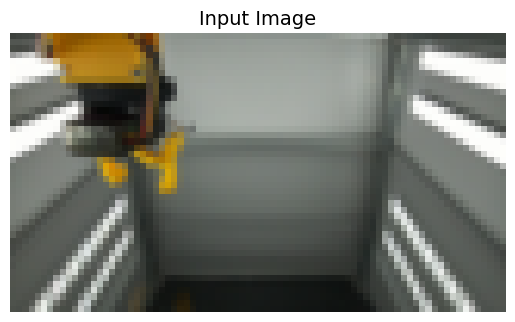

In [12]:
show_sample_encoder_prediction_vs_target(test_dataset, conv_encoder_trainer, idx=0)

# Decoder

## Fourier MLP decoder

Print available trained models

In [46]:
from architecture import FourierMlpDecoder
dir = "trained_models_cluster"
decoder_type = "fourier_mlp_decoder"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Fourier MLP Decoders:", *trained_decoders, sep="\n- ")

Available trained Fourier MLP Decoders:
- MSE_val10000_batch32_xyzrg


#### Decoder trained with MSE Loss

Load model, trainer and configuration

In [47]:
MODEL_TO_LOAD = "MSE_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
fourier_mlp_decoder, fourier_mlp_decoder_trainer, config = load_model(FourierMlpDecoder, model_path)

Evaluation on test set <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [51]:
print("Evaluation on test set:")
dataset_metrics = fourier_mlp_decoder_trainer.evaluate_model(test_loader)

Evaluation on test set:


Testing:   0%|          | 0/313 [00:00<?, ?it/s]

MSE loss: 0.0025
LPIPS loss: 0.1735
SSIM loss: 0.8941
PSNR loss: 26.0144
RMSE loss: 0.0503


___
Demo to visualize desired configuration in input, reconstruction and target image $\newline$
on the test set of the clean environment dataset

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0041
LPIPS loss: 0.2515
SSIM loss: 0.8233
PSNR loss: 23.8994
RMSE loss: 0.0638
Robot configuration x=0.154, y=0.170, z=0.278, r=0.939, g=0.200


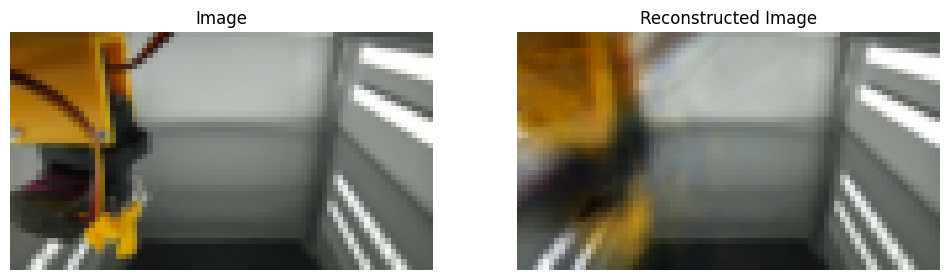

In [52]:
slider_input_vs_reconstruction(test_dataset, fourier_mlp_decoder_trainer)
show_sample_input_vs_reconstruction(test_dataset, fourier_mlp_decoder_trainer, idx=0)

#### Decoder trained with LPIPS Loss

In [ ]:
decoder_type = "fourier_mlp_decoder"
trained_decoders = os.listdir(os.path.join("trained_models", decoder_type))
print("Available trained decoders:", *trained_decoders, sep="\n- ")

Available trained decoders:
- debug_config_train32_val32_batch32_xyzrg
- debug_datapath_train32_val32_batch32_xyzrg
- debug_freq_train32_val32_batch32_xyzrg
- debug_logger_train32_val32_batch32_xyzrg
- debug_lpips_train32_val32_batch32_xyzrg
- debug_reconstruction_train32_val32_batch32_xyzrg
- debug_save_load_train32_val32_batch32_xyzrg
- debug_train32_val32_batch32_xyzrg
- freq_32_train32_val32_batch32_xyzrg
- freq_64_train32_val32_batch32_xyzrg
- MSE_val10000_batch32_xyzrg_cluster
- train32_val32_batch32_xyzrg


In [ ]:
MODEL_TO_LOAD = "train32_val32_batch32_xyzrg"

In [14]:
from architecture import FourierMlpDecoder

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, # TODO: local config
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
summary(decoder, input_size=(1, len(config["model"]["dimensions_to_learn"])))
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.020593509078025818
Train batch-loss RMSE: 0.1435043869643915
Output shape: (32, 3, 45, 80)
Robot configuration x=0.460, y=0.500, z=0.050, r=0.000, g=1.000


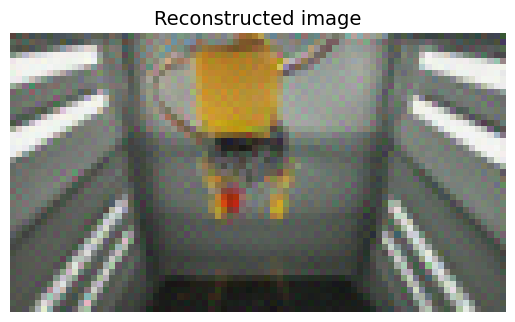

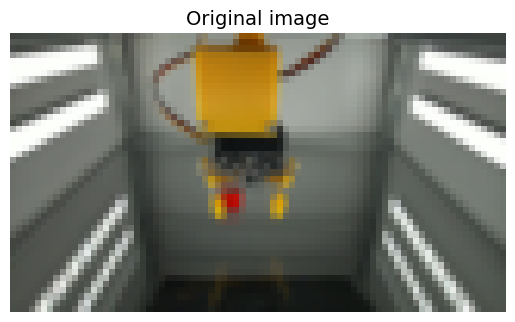

In [15]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

 inference on test set

Inference on test set:
Test loss MSE: 0.1273220181465149
Test loss RMSE: 0.35682210994627966
Output shape: (32, 3, 45, 80)
Robot configuration x=0.810, y=0.500, z=0.289, r=0.000, g=1.000


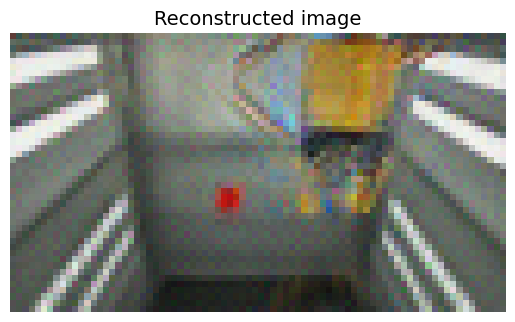

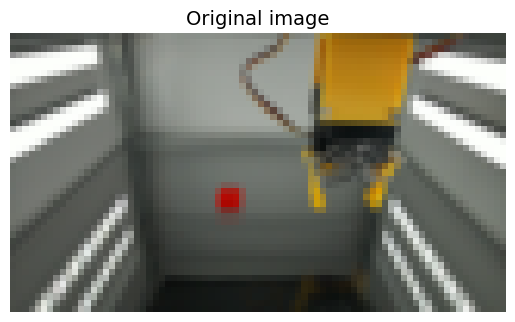

In [18]:
batch = next(iter(test_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Inference on test set:")
print("Test loss MSE:", loss)
print("Test loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")


In [4]:
MODEL_TO_LOAD = "MSE_val10000_batch32_xyzrg_cluster"

In [5]:
from architecture import FourierMlpDecoder

model_path = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD)
config_file = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    config["data"]["dataset_path"] = os.getenv("DATASET_PATH_BIG")

# dataset
train_loader, val_loader, test_loader = get_data(config)

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
# decoder.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.002905134577304125
Train batch-loss RMSE: 0.053899300341508374
Output shape: (32, 3, 45, 80)
Robot configuration x=0.676, y=0.836, z=0.433, r=0.117, g=0.322


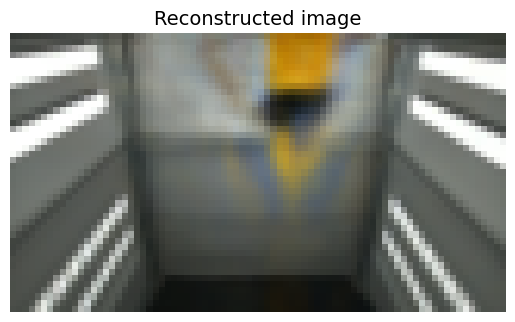

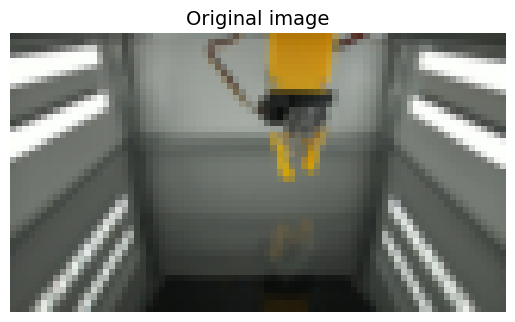

In [11]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.clamp(0, 1).detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 10
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

## Conditioned UNet

In [9]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"

trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Conditioned UNet with FiLM:", *trained_decoders, sep="\n- ")

Available trained Conditioned UNet with FiLM:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg


### cUNet with 1 reference

The cUNet uses as input always the same single reference image for all samples.

In [115]:
MODEL_TO_LOAD = "cnet_1ref_val10000_batch32_xyzrg"

In [116]:
# load model config
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
config_file = os.path.join(dir, decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

# load trained model
unet_1ref = UNetWithFiLM(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
unet_1ref.load_model(model_path)
unet_1ref = accelerator.prepare(unet_1ref)
# unet_1ref.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
unet_1ref.eval()
unet_1ref_trainer = Trainer(unet_1ref, config)

Evaluation on test set

- original test set
- toy test set

In [43]:
print("Evaluation on test set:")
dataset_metrics = unet_1ref_trainer.evaluate_model(ref_test_loader)

print("\nEvaluation on test toy dataset:")
toy_dataset_metrics = unet_1ref_trainer.evaluate_model(ref_toy_test_loader)

Evaluation on test set:


MSE loss: 0.0227
LPIPS loss: 0.3201
RMSE loss: 0.1506

Evaluation on test toy dataset:


MSE loss: 0.0122
LPIPS loss: 0.2631
RMSE loss: 0.1104


Demo

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [117]:
slider_reference_vs_reconstruction_vs_target(ref_test_dataset, unet_1ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0227
LPIPS loss: 0.3379
RMSE loss: 0.1505
Robot configuration x=0.694, y=0.968, z=0.072, r=0.550, g=0.667


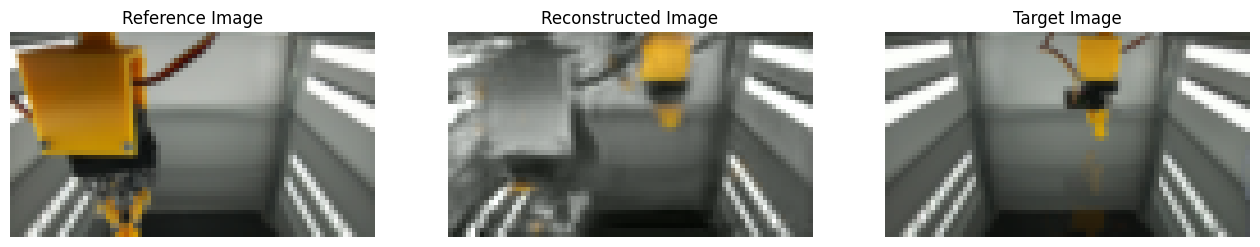

In [ ]:
show_sample_reference_vs_reconstruction_vs_target(ref_test_dataset, unet_1ref_trainer, idx=8)

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the toy dataset (not used for training) with an object in the environment.

In [118]:
slider_reference_vs_reconstruction_vs_target(ref_toy_test_dataset, unet_1ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0120
LPIPS loss: 0.2974
RMSE loss: 0.1094
Robot configuration x=0.840, y=0.500, z=0.400, r=0.000, g=1.000


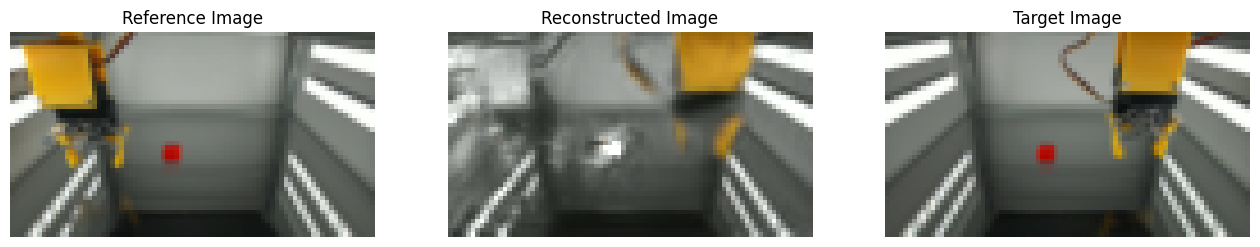

In [50]:
show_sample_reference_vs_reconstruction_vs_target(ref_toy_test_dataset, unet_1ref_trainer, idx=8)

### cUNet with 10 references

In [26]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Conditioned-UNet with 10 references images decoders:", *trained_decoders, sep="\n- ")

Available trained Conditioned-UNet with 10 references images decoders:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg


In [27]:
MODEL_TO_LOAD = "unet_10ref_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_10ref, unet_10ref_trainer, config = load_model(UNetWithFiLM, model_path)

Evaluation on test set

- original test set
- toy test set

In [31]:
print("Evaluation on test set:")
dataset_metrics = unet_10ref_trainer.evaluate_model(test_loader_10ref)

print("\nEvaluation on test toy dataset")
toy_dataset_metrics = unet_10ref_trainer.evaluate_model(toy_test_loader_10ref)

Evaluation on test set:


MSE loss: 0.0020
LPIPS loss: 0.1049
RMSE loss: 0.0443

Evaluation on test toy dataset


MSE loss: 0.0023
LPIPS loss: 0.1267
RMSE loss: 0.0477


Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [28]:
slider_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0014
LPIPS loss: 0.0836
RMSE loss: 0.0370
Robot configuration x=0.207, y=0.507, z=0.128, r=0.594, g=0.567


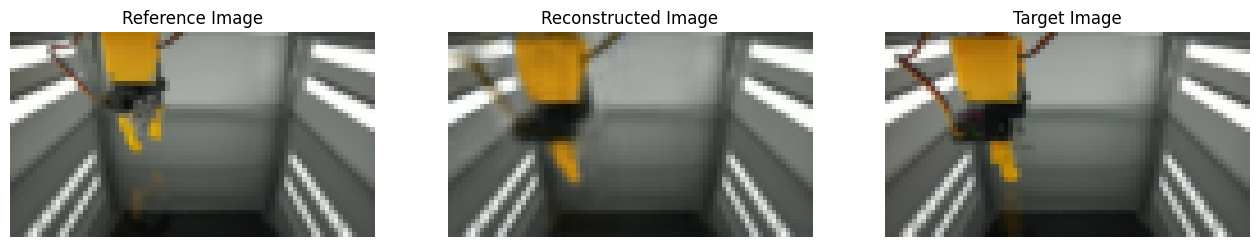

In [113]:
show_sample_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_trainer, idx=8)

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the toy dataset (not used for training) with an object in the environment.

In [114]:
slider_reference_vs_reconstruction_vs_target(toy_test_dataset_10ref, unet_10ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0019
LPIPS loss: 0.1292
RMSE loss: 0.0440
Robot configuration x=0.070, y=0.500, z=0.150, r=0.000, g=1.000


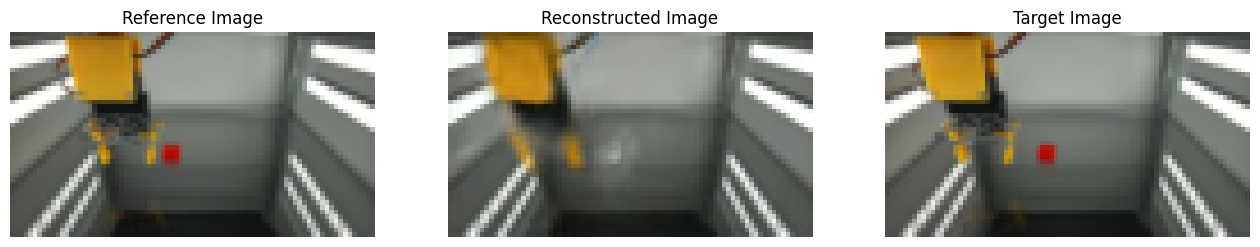

In [55]:
show_sample_reference_vs_reconstruction_vs_target(toy_test_dataset_10ref, unet_10ref_trainer, idx=0)

### cUNet with 10 references + background image

In [11]:
from conditioned_UNet import UNetWithFiLMAndEnv
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m_and_env"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Convolutional Decoders:", *trained_decoders, sep="\n- ")

Available trained Convolutional Decoders:
- unet_10ref_background_val10000_batch32_xyzrg


In [ ]:
MODEL_TO_LOAD = "unet_10ref_background_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_10ref_env, unet_10ref_env_trainer, config = load_model(UNetWithFiLMAndEnv, model_path)

In [10]:
print("Evaluation on test set:")
dataset_metrics = unet_10ref_env_trainer.evaluate_model(test_loader_10ref)

print("\nEvaluation on test toy dataset")
toy_dataset_metrics = unet_10ref_env_trainer.evaluate_model(toy_test_loader_10ref)

Evaluation on test set:


MSE loss: 0.0014
LPIPS loss: 0.0790
RMSE loss: 0.0368

Evaluation on test toy dataset


MSE loss: 0.0022
LPIPS loss: 0.1129
RMSE loss: 0.0464


Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [34]:
slider_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_env_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0007
LPIPS loss: 0.0478
RMSE loss: 0.0259
Robot configuration x=0.694, y=0.968, z=0.072, r=0.550, g=0.667


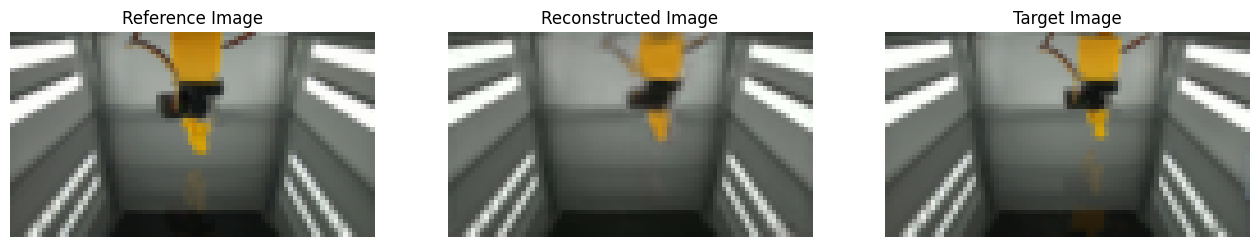

In [11]:
show_sample_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_env_trainer, idx=8)

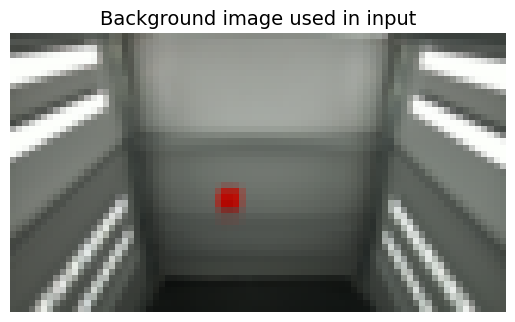

In [35]:
toy_train_loader = DataLoader(toy_train_dataset, batch_size=200, shuffle=True)
images, labels = next(iter(toy_train_loader))
median_img = torch.median(images, dim=0).values

unet_10ref_env_trainer.model.background_image = median_img.unsqueeze(0).to(unet_10ref_env_trainer.model.device)
from gripper_data import plot_image
plot_image(unet_10ref_env_trainer.model.background_image[0].cpu(), title="Background image used in input")


In [ ]:
# use different background image in input
slider_reference_vs_reconstruction_vs_target(toy_test_dataset_10ref, unet_10ref_env_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0016
LPIPS loss: 0.1009
RMSE loss: 0.0405
Robot configuration x=0.800, y=0.500, z=0.550, r=0.000, g=1.000


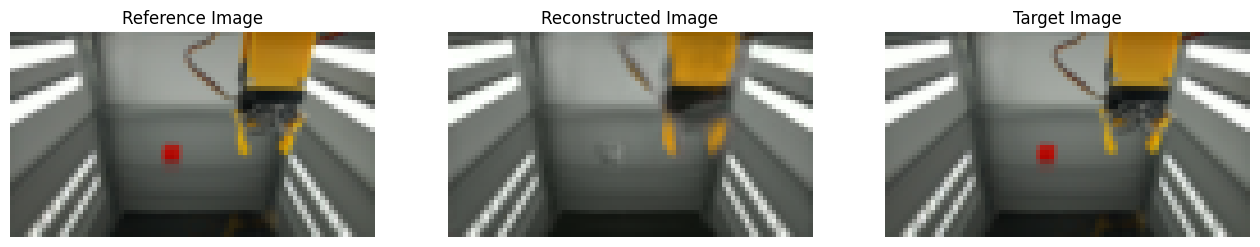

In [38]:
show_sample_reference_vs_reconstruction_vs_target(toy_test_dataset_10ref, unet_10ref_env_trainer, idx=1)

### cUNet with 60 references

In [43]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Conditioned-UNet with 10 references images decoders:", *trained_decoders, sep="\n- ")

Available trained Conditioned-UNet with 10 references images decoders:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg


In [44]:
MODEL_TO_LOAD = "unet_60ref_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_60ref, unet_60ref_trainer, config = load_model(UNetWithFiLM, model_path)

Evaluation on test set

- original test set
- toy test set

In [ ]:
print("Evaluation on test set:")
dataset_metrics = unet_60ref_trainer.evaluate_model(test_loader_60ref)

print("\nEvaluation on test toy dataset")
toy_dataset_metrics = unet_60ref_trainer.evaluate_model(toy_test_loader_60ref)

Evaluation on test set:


KeyboardInterrupt: 

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [ ]:
slider_reference_vs_reconstruction_vs_target(test_dataset_60ref, unet_60ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0014
LPIPS loss: 0.0836
RMSE loss: 0.0370
Robot configuration x=0.207, y=0.507, z=0.128, r=0.594, g=0.567


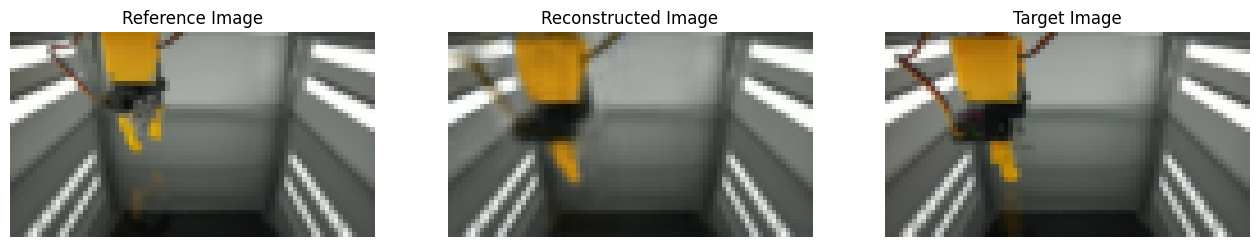

In [ ]:
show_sample_reference_vs_reconstruction_vs_target(test_dataset_60ref, unet_60ref_trainer, idx=8)

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the toy dataset (not used for training) with an object in the environment.

In [ ]:
slider_reference_vs_reconstruction_vs_target(toy_test_dataset_60ref, unet_60ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0019
LPIPS loss: 0.1292
RMSE loss: 0.0440
Robot configuration x=0.070, y=0.500, z=0.150, r=0.000, g=1.000


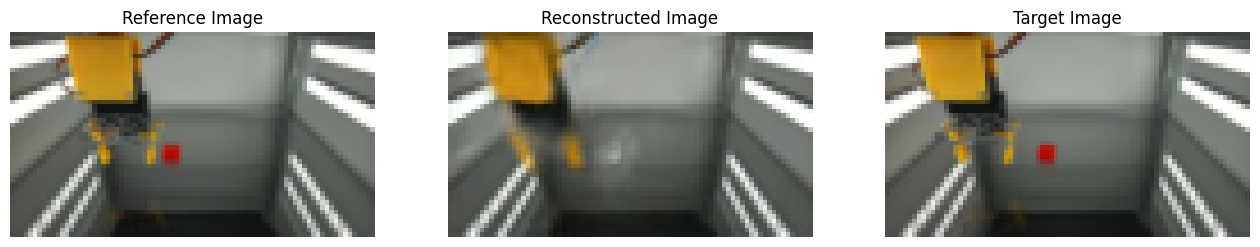

In [ ]:
show_sample_reference_vs_reconstruction_vs_target(toy_test_dataset_60ref, unet_60ref_trainer, idx=0)

### cUNet with 60 references selected from grid in the configuration space

## Encoding with decoder

In [18]:
print(unet_10ref_trainer.model.__class__.__name__)

UNetWithFiLM


In [85]:
from training import DECODERS, ARCHITECTURES_WITH_REFERENCE
def encode_with_decoder(self, 
                        image, 
                        encoder=None, # encoder for initializing latent space config, otherwise random
                        reference_image=None, # reference images for architectures with reference
                        threshold=0.001, 
                        max_iterations=100, 
                        verbose=False):
        """
        Generate images reconstructions with the decoder
        until the distance (LPIPS) between the input image and the reconstruction is below a certain threshold
        by searching the latent space with GD
        """
        if self.model.__class__.__name__ not in DECODERS:
            raise ValueError(f"The model must be a decoder to use this method, not {self.model.__class__.__name__}.")

        image = image.unsqueeze(0)
        reference_image = reference_image.unsqueeze(0) if reference_image is not None else None

        # Initialize latent/config vector (requires_grad=True for optimization) with encoder or random
        if encoder is not None:
            encoder.model.eval()
            with torch.no_grad():
                latent = encoder.model(image)
                latent.requires_grad = True
        else:
            latent = torch.rand(1, len(self.dimensions_to_learn),
                                    device=self.accelerator.device,
                                    requires_grad=True
                                )
        initial_latent = latent.clone().detach()
        # if verbose:
        #     print(f"Starting encoding with decoder, initial guess: {[round(val, 4) for val in latent[0].tolist()]}")

        optimizer = torch.optim.Adam([latent], lr=0.001)
        best_latent = latent.clone().detach()
        best_loss = float("inf")
        last_distance = None

        for i in range(max_iterations):
            if self.model.__class__.__name__ in ARCHITECTURES_WITH_REFERENCE:
                if reference_image is None:
                    raise ValueError("Reference image must be provided for architectures with reference.")
                
                # select closest reference 
                # closest_ref_img_idx = torch.min([self.eval_loss_functions["LPIPS"](ref_img, image) for ref_img in references])
                # closest_ref_img = references[closest_ref_img_idx].unsqueeze(0)
                # reconstructed_image = self.model(closest_ref_img, latent)
                reconstructed_image = self.model(reference_image, latent)
            else:
                reconstructed_image = self.model(latent)
            lpips_distance = self.eval_loss_functions["LPIPS"](reconstructed_image.clamp(0,1), image.clamp(0,1))
            # print(f"Iteration {i+1}, LPIPS={lpips_distance.item():.7f}")

            optimizer.zero_grad()
            lpips_distance.backward()
            optimizer.step()

            if lpips_distance.item() < best_loss:
                best_loss = lpips_distance.item()
                best_latent = latent.clone().detach()

            if last_distance is not None and abs(last_distance - lpips_distance.item()) < threshold:
                if verbose:
                    print(f"Converged after {i+1} iterations, LPIPS={lpips_distance.item():.7f})")
                break
            last_distance = lpips_distance.item()

        if verbose and i>=max_iterations-1:
            print(f"Did not converge after {max_iterations} iterations, final best LPIPS={best_loss:.7f}")
        return initial_latent, best_latent, best_loss

In [87]:
reference_images, reference_states = dataset_10ref.get_references()

# slider

def call(dataset):
    @interact(idx=(0, len(dataset)-1))
    def update_slider(idx):
        images, labels, references, ref_labels = dataset[idx]
        image = images
        initial_prediction,predicted_label, lpips_distance = encode_with_decoder(self=unet_10ref_trainer,
                            image=image,
                            encoder=conv_encoder_trainer,
                            reference_image=references, 
                            threshold=0.000001,
                            max_iterations=50,
                            verbose=True)
        # compute metrics
        # rmse per dimension
        print(f"Target label:\t\t{[round(val,4) for val in labels.tolist()]}")
        rmse = torch.sqrt(torch.mean((initial_prediction.squeeze() - labels)**2)).item()
        rmse_per_dim = torch.sqrt(torch.mean((initial_prediction - labels)**2, dim=0)).tolist()
        print(f"Initial label:\t\t{[round(val,4) for val in initial_prediction[0].tolist()]}, RMSE: {rmse:.4f}, RMSE per dim: {[round(val,4) for val in rmse_per_dim]}")
        
        rmse = torch.sqrt(torch.mean((predicted_label.squeeze() - labels)**2)).item()
        rmse_per_dim = torch.sqrt(torch.mean((predicted_label - labels)**2, dim=0)).tolist()
        print(f"Predicted label:\t{[round(val,4) for val in predicted_label[0].tolist()]}, RMSE: {rmse:.4f}, RMSE per dim: {[round(val,4) for val in rmse_per_dim]}")

call(test_dataset_10ref)



interactive(children=(IntSlider(value=4999, description='idx', max=9999), Output()), _dom_classes=('widget-int…

In [91]:
# evaluation on test set with encoding
running_loss = 0.0
from tqdm import tqdm
for i in tqdm(range(len(test_dataset_10ref))):
    images, labels, references, ref_labels = test_dataset_10ref[i]
    image = images
    initial_prediction,predicted_label, lpips_distance = encode_with_decoder(self=unet_10ref_trainer,
                        image=image,
                        encoder=conv_encoder_trainer,
                        reference_image=references, 
                        threshold=0.000001,
                        max_iterations=50,
                        verbose=False)
    # compute metrics
    # mse
    running_loss += torch.mean((predicted_label.squeeze() - labels)**2).item()
    if i>=999:
        break

mse = running_loss / 1000 #len(test_dataset_10ref)
rmse = mse**0.5
print(f"Test set encoding with decoder - MSE: {mse:.6f}, RMSE: {rmse:.6f}")

    # rmse = torch.sqrt(torch.mean((predicted_label.squeeze() - labels)**2)).item()
    # rmse_per_dim = torch.sqrt(torch.mean((predicted_label - labels)**2, dim=0)).tolist()
    # print(f"Sample {i}: Predicted label: {[round(val,4) for val in predicted_label[0].tolist()]}, RMSE: {rmse:.4f}, RMSE per dim: {[round(val,4) for val in rmse_per_dim]}")

  3%|▎         | 285/10000 [1:11:03<40:22:28, 14.96s/it]


KeyboardInterrupt: 

In [94]:
print(i) # iteration i not finished
mse = running_loss / i
rmse = mse**0.5
print(f"Test set encoding with decoder - MSE: {mse:.6f}, RMSE: {rmse:.6f}")

285
Test set encoding with decoder - MSE: 0.002535, RMSE: 0.050345


# Final

Models:

- cUNet with 10 references 

- cUNet with 10 references + background
- cUNet with 10 references + delta label
- cUNet with 10 references + weights

- cUNet with 10 references + background +  delta label
- cUNet with 10 references + background + weights

### cUNet with 10 references + background 

Print available trained models

In [168]:
from conditioned_UNet import UNetWithFiLMAndEnv
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m_and_env"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Convolutional Decoders:", *trained_decoders, sep="\n- ")

Available trained Convolutional Decoders:
- unet_10ref_background_val10000_batch32_xyzrg
- unet_env_delta_ref10_delta_val10000_batch32_xyzrg
- unet_env_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [169]:
MODEL_TO_LOAD = "unet_10ref_background_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_10ref_env, unet_10ref_env_trainer, config, references_indices = load_model(UNetWithFiLMAndEnv, model_path)

No background image found.


Load datasets with training references and random references, split and create loaders

In [170]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [49443, 94015, 79186, 90408, 43732, 949, 7427, 81490, 48305, 40379]


Compute background image from training dataset if needed (if it's not already in the model folder)

In [171]:
if unet_10ref_env.background_image is None:
    unet_10ref_env.create_background_image(datasets_ref["train"])
# plot
# from gripper_data import plot_image
# plot_image(unet_10ref_env.background_image[0].cpu(), title="Background image")

Evaluation on test set with training references VS random references <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [173]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_10ref_env_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_10ref_env_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0014
LPIPS loss: 0.0865
SSIM loss: 0.9427
PSNR loss: 28.7203
RMSE loss: 0.0368


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

- with random references

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0011
LPIPS loss: 0.0926
SSIM loss: 0.9553
PSNR loss: 29.4184
RMSE loss: 0.0338
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


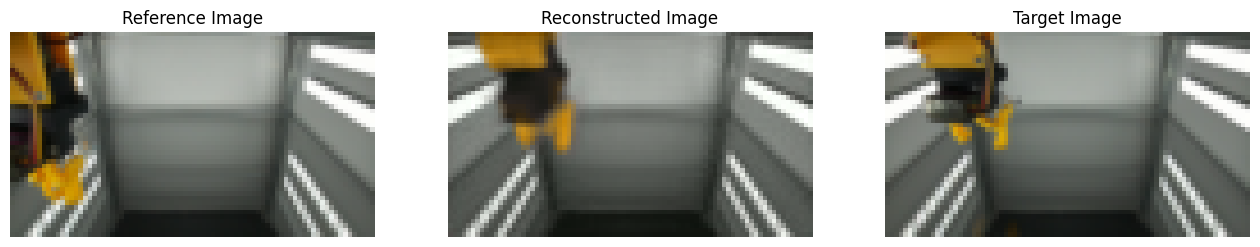

In [174]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_10ref_env_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_10ref_env_trainer, idx=0) # placeholder

In [175]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_10ref_env_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_10ref_env_trainer, idx=0) # placeholder

___

### cUNet with 1 reference 

Print available trained models

In [176]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg
- unet_delta_ref10_delta_val10000_batch32_xyzrg
- unet_ref10_val10000_batch32_xyzrg
- unet_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [177]:
MODEL_TO_LOAD = "cnet_1ref_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
cnet_1ref, cnet_1ref_trainer, config, references_indices = load_model(UNetWithFiLM, model_path)

Load datasets with training references and random references, split and create loaders

In [178]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training: [0]")

# # dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=1, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

References used for training: [0]


Evaluation on test set with training references VS random references <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [182]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = cnet_1ref_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = cnet_1ref_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0224
LPIPS loss: 0.3194
SSIM loss: 0.5748
PSNR loss: 16.5059
RMSE loss: 0.1496


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

- with random references

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0184
LPIPS loss: 0.2597
SSIM loss: 0.6424
PSNR loss: 17.3496
RMSE loss: 0.1357
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


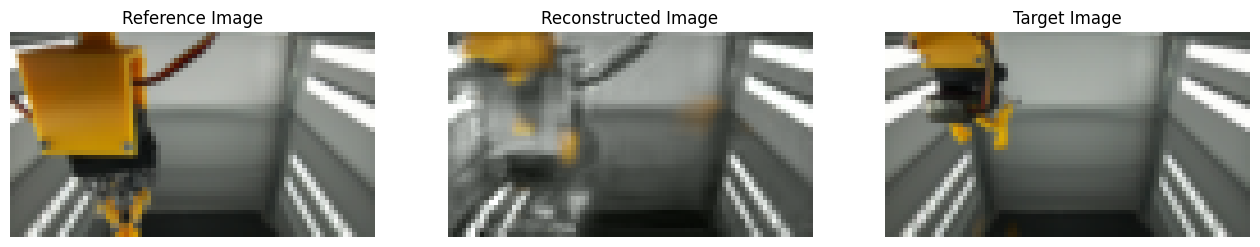

In [183]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], cnet_1ref_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], cnet_1ref_trainer, idx=0) # placeholder

In [184]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], cnet_1ref_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], cnet_1ref_trainer, idx=0) # placeholder

### cUNet with 10 references + background + delta labels

Print available trained models

In [148]:
from conditioned_UNet import UNetWithFiLMAndEnv
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m_and_env"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m_and_env:
- unet_10ref_background_val10000_batch32_xyzrg
- unet_env_delta_ref10_delta_val10000_batch32_xyzrg
- unet_env_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [121]:
MODEL_TO_LOAD = "unet_env_delta_ref10_delta_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_env_ref10_delta, unet_env_ref10_delta_trainer, config, references_indices = load_model(UNetWithFiLMAndEnv, model_path)

Load datasets with training references and random references, split and create loaders

In [149]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [27651, 80189, 29863, 23129, 90887, 16909, 1607, 33235, 48430, 96925]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [151]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_env_ref10_delta_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_env_ref10_delta_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0014
LPIPS loss: 0.0883
SSIM loss: 0.9387
PSNR loss: 28.4846
RMSE loss: 0.0379


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0013
LPIPS loss: 0.0788
SSIM loss: 0.9513
PSNR loss: 28.9769
RMSE loss: 0.0356
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


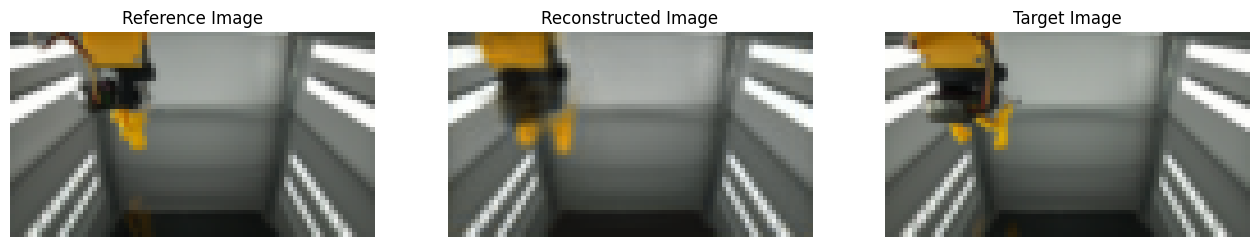

In [152]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_env_ref10_delta_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_env_ref10_delta_trainer, idx=0) # placeholder

In [153]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_env_ref10_delta_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_env_ref10_delta_trainer, idx=0) # placeholder

___

### cUNet with 10 references + delta labels

Print available trained models

In [154]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg
- unet_delta_ref10_delta_val10000_batch32_xyzrg
- unet_ref10_val10000_batch32_xyzrg
- unet_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [155]:
MODEL_TO_LOAD = "unet_delta_ref10_delta_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_ref10_delta, unet_ref10_delta_trainer, config, references_indices = load_model(UNetWithFiLM, model_path)

Load datasets with training references and random references, split and create loaders

In [156]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [49443, 94015, 79186, 90408, 43732, 949, 7427, 81490, 48305, 40379]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [157]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_ref10_delta_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_env_ref10_delta_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


Testing:   0%|          | 0/313 [00:00<?, ?it/s]

MSE loss: 0.0024
LPIPS loss: 0.1233
SSIM loss: 0.9130
PSNR loss: 26.3468
RMSE loss: 0.0485


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0046
LPIPS loss: 0.1211
SSIM loss: 0.8899
PSNR loss: 23.3816
RMSE loss: 0.0678
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


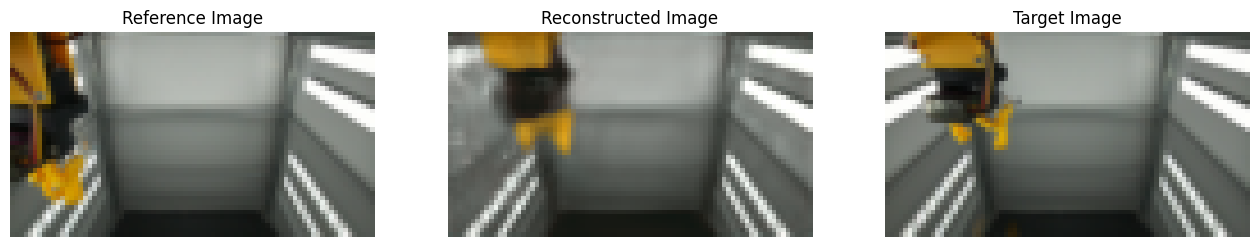

In [158]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_delta_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_delta_trainer, idx=0) # placeholder

In [159]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_delta_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_delta_trainer, idx=0) # placeholder

___

### cUNet with 10 references

Print available trained models

In [160]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg
- unet_delta_ref10_delta_val10000_batch32_xyzrg
- unet_ref10_val10000_batch32_xyzrg
- unet_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [161]:
MODEL_TO_LOAD = "unet_ref10_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_ref10, unet_ref10_trainer, config, references_indices = load_model(UNetWithFiLM, model_path)

Load datasets with training references and random references, split and create loaders

In [162]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [49443, 94015, 79186, 90408, 43732, 949, 7427, 81490, 48305, 40379]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [165]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_ref10_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_env_ref10_delta_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0027
LPIPS loss: 0.1212
SSIM loss: 0.9101
PSNR loss: 25.7731
RMSE loss: 0.0521


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0061
LPIPS loss: 0.1274
SSIM loss: 0.8630
PSNR loss: 22.1381
RMSE loss: 0.0782
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


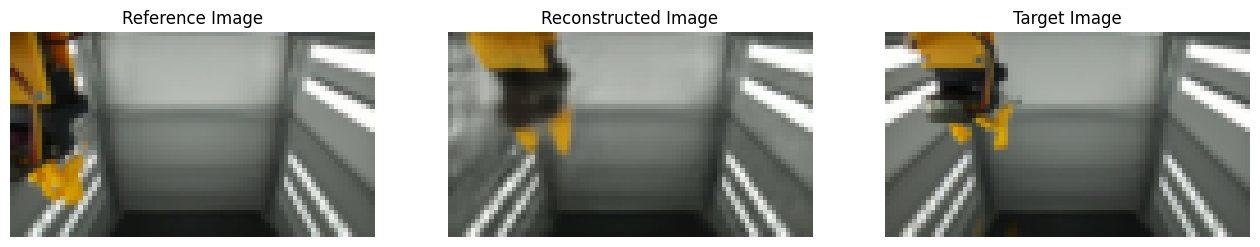

In [166]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_trainer, idx=0) # placeholder

In [167]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_trainer, idx=0) # placeholder

___

### cUNet with 10 references + weights

Print available trained models

In [7]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg
- unet_delta_ref10_delta_val10000_batch32_xyzrg
- unet_ref10_val10000_batch32_xyzrg
- unet_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [8]:
MODEL_TO_LOAD = "unet_ref10_w15143_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_ref10_w15143, unet_ref10_w15143_trainer, config, references_indices = load_model(UNetWithFiLM, model_path)

Load datasets with training references and random references, split and create loaders

In [9]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [27651, 80189, 29863, 23129, 90887, 16909, 1607, 33235, 48430, 96925]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [11]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_ref10_w15143_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_ref10_w15143_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0021
LPIPS loss: 0.1129
SSIM loss: 0.9220
PSNR loss: 26.8524
RMSE loss: 0.0458


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0016
LPIPS loss: 0.0838
SSIM loss: 0.9385
PSNR loss: 27.8594
RMSE loss: 0.0405
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


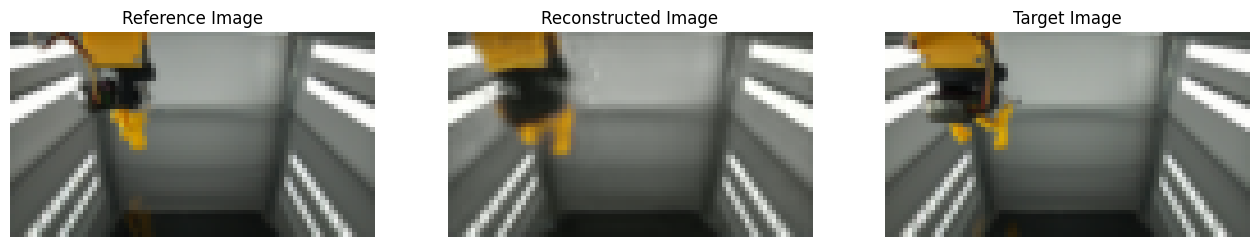

In [12]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_w15143_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref10_w15143_trainer, idx=0) # placeholder

In [13]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_w15143_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref10_w15143_trainer, idx=0) # placeholder

___

### cUNet with 10 references + background + weights

Print available trained models

In [14]:
from conditioned_UNet import UNetWithFiLMAndEnv
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m_and_env"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m_and_env:
- unet_10ref_background_val10000_batch32_xyzrg
- unet_env_delta_ref10_delta_val10000_batch32_xyzrg
- unet_env_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [15]:
MODEL_TO_LOAD = "unet_env_ref10_w15143_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_env_ref10_w15143, unet_env_ref10_w15143_trainer, config, references_indices = load_model(UNetWithFiLMAndEnv, model_path)

Load datasets with training references and random references, split and create loaders

In [16]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 10
References used for training: [27651, 80189, 29863, 23129, 90887, 16909, 1607, 33235, 48430, 96925]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [17]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_env_ref10_w15143_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_env_ref10_w15143_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0012
LPIPS loss: 0.0765
SSIM loss: 0.9481
PSNR loss: 29.1213
RMSE loss: 0.0352


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0011
LPIPS loss: 0.0828
SSIM loss: 0.9594
PSNR loss: 29.6532
RMSE loss: 0.0329
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


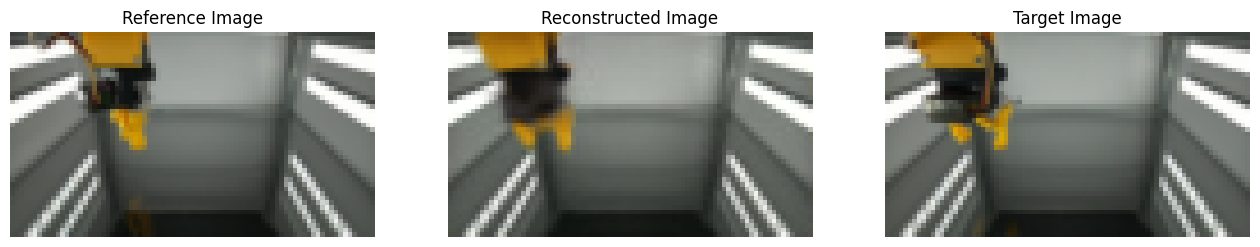

In [ ]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_env_ref10_w15143_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_env_ref10_w15143_trainer, idx=0) # placeholder

In [19]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_env_ref10_w15143_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_env_ref10_w15143_trainer, idx=0) # placeholder

___

### cUNet with 60 references

Print available trained models

In [185]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print(f"Available trained {decoder_type}:", *trained_decoders, sep="\n- ")

Available trained u_net_with_fi_l_m:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg
- unet_60ref_grid15143_val10000_batch32_xyzrg
- unet_60ref_val10000_batch32_xyzrg
- unet_delta_ref10_delta_val10000_batch32_xyzrg
- unet_ref10_val10000_batch32_xyzrg
- unet_ref10_w15143_val10000_batch32_xyzrg


Load model, trainer, configuration, and reference indices 

In [186]:
MODEL_TO_LOAD = "unet_60ref_val10000_batch32_xyzrg"
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
unet_ref60, unet_ref60_trainer, config, references_indices = load_model(UNetWithFiLM, model_path)

Load datasets with training references and random references, split and create loaders

In [187]:
if references_indices:
    num_references = len(references_indices)
    print(f"Number of references used in training: {num_references}")
    
# dataset with references used in training
datasets_ref, loaders_ref =load_dataset(path=FULL_DATASET_PATH, 
                                        split=FULL_DATASET_SPLIT, 
                                        references=True,
                                        validation_split=[10000,10000], 
                                        reference_indices=references_indices)
print("References used for training:", datasets_ref["all"].ref_indices.tolist())

# dataset with random references
# random_references = np.random.choice(len(datasets_ref["all"]), size=num_references, replace=False).tolist()
# datasets_rand_ref, loaders_rand_ref = load_dataset(path=FULL_DATASET_PATH, 
#                                                     split=FULL_DATASET_SPLIT, 
#                                                     references=True,
#                                                     validation_split=[10000,10000], 
#                                                     reference_indices=random_references)
# print("Random references:", datasets_rand_ref["all"].ref_indices.tolist())

Number of references used in training: 60
References used for training: [89729, 69020, 95454, 40539, 74038, 27479, 5731, 35214, 30152, 97014, 68139, 70484, 69391, 18958, 77843, 88367, 9543, 65802, 39795, 51194, 74791, 74936, 86203, 9975, 23612, 5626, 32584, 28736, 98453, 44558, 44145, 33438, 40884, 41402, 48230, 57906, 68603, 85100, 51196, 43374, 17453, 30676, 26315, 53333, 39501, 91904, 25812, 37102, 20337, 97951, 40915, 31330, 37868, 26841, 16954, 30917, 3797, 22261, 70733, 86081]


Evaluation on test set with references used for training <br>
using the following metrics: MSE, LPIPS, SSIM, PSNR, RMSE

In [192]:
# evaluation
print("\nEvaluation on test set with training references:")
metrics = unet_ref60_trainer.evaluate_model(loaders_ref["test"])

# print("\nEvaluation on test set with random references:")
# metrics_rand_ref = unet_ref60_trainer.evaluate_model(loaders_rand_ref["test"])


Evaluation on test set with training references:


MSE loss: 0.0022
LPIPS loss: 0.1020
SSIM loss: 0.9248
PSNR loss: 26.7569
RMSE loss: 0.0464


___
Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

- with references used in training

Visualization on test set with training references:


interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

MSE loss: 0.0037
LPIPS loss: 0.0917
SSIM loss: 0.9026
PSNR loss: 24.2673
RMSE loss: 0.0612
Robot configuration x=0.088, y=0.488, z=0.906, r=0.972, g=0.667


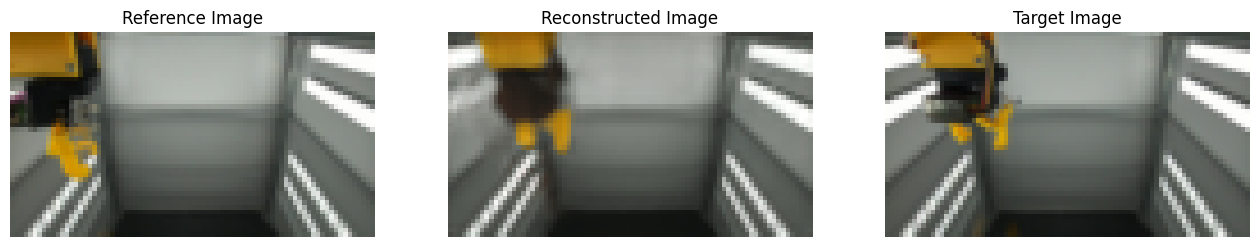

In [193]:
print("Visualization on test set with training references:")
slider_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref60_trainer)
show_sample_reference_vs_reconstruction_vs_target(datasets_ref["test"], unet_ref60_trainer, idx=0) # placeholder

In [ ]:
# print("Visualization on test set with random references:")
# slider_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref60_trainer)
# show_sample_reference_vs_reconstruction_vs_target(datasets_rand_ref["test"], unet_ref60_trainer, idx=0) # placeholder

___